# 07 IEEE 2890-2025 Provenance: Full Lifecycle
**Repo:** local_contexts_geospatial  
**Author:** Lilly Jones, PhD, Daear Consulting, LLC  

## What Is IEEE 2890-2025?
IEEE 2890-2025 *Recommended Practice for Provenance of Indigenous
Peoples' Data* is the first international standard specifically
addressing the provenance of data about Indigenous Peoples.

Published November 2025, it establishes:
- Common parameters for describing where Indigenous data came from
- How data should be connected to people and place
- How governance responsibilities travel with data through transformations
- Controlled vocabulary for provenance metadata
- Alignment with CARE, FAIR, and Local Contexts frameworks

Reference: https://standards.ieee.org/ieee/2890/10318/

## What This Notebook Covers
This is the capstone notebook that implements the full data lifecycle:

1. **Origin** document where data came from and who it is about
2. **Ingest** attach TK label and build provenance record at load time
3. **Transform** add provenance steps as each transformation runs
4. **Validate** check label and consent at each decision point
5. **Export** write output with embedded provenance and sidecar JSON
6. **Verify** reload and confirm provenance chain is intact

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import warnings
import datetime
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from localcontexts.labels import TKLabel, TKMetadata, has_any_label
from localcontexts.propagation import propagate_labels, add_provenance_step
from localcontexts.validation import (
    validate_usage,
    validate_provenance_intact,
    validate_export_ready,
    check_collective_benefit,
    check_authority_to_control,
    TKViolationError,
)
from localcontexts.provenance import (
    ProvenanceOrigin,
    ProvenanceStep,
    ProvenanceRecord,
    build_sidecar_path,
    attach_provenance_to_meta,
    extract_provenance_from_meta,
)

warnings.filterwarnings("ignore", category=FutureWarning)

SYNTH_DIR  = REPO_ROOT/"data"/"synthetic"
OUTPUT_DIR = REPO_ROOT/"outputs"
SYNTH_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Imports complete.")
print(f"IEEE 2890-2025: https://standards.ieee.org/ieee/2890/10318/")

Imports complete.
IEEE 2890-2025: https://standards.ieee.org/ieee/2890/10318/


## Origin: Document the Source

In [2]:
# ProvenanceOrigin captures the dataset's root provenance:
# what it is about, where it came from, and what cultural authority it carries

origin = ProvenanceOrigin(
    subject        = "NDVI time series for Pine Ridge Oglala Lakota Nation",
    community      = "Oglala Lakota Nation",
    territory      = "Pine Ridge Reservation, South Dakota",
    source_name    = "MODIS MOD13Q1 V061 via ORNL DAAC MODIS Web Service",
    source_url     = "https://modis.ornl.gov/rst/api/v1/",
    source_steward = "NASA ORNL DAAC",
    obtained_date  = datetime.date.today().isoformat(),
    tk_label       = TKLabel.NON_COMMERCIAL.value,
    label_authority= "Tribal Data Governance Office, Oglala Lakota Nation",
    license        = "NASA data use policy: open for non-commercial research",
    access_conditions = (
        "TK Non-Commercial label applies. Results must be shared with "
        "the Tribal Data Governance Office before publication."
    ),
)

print("ProvenanceOrigin:")
print(json.dumps(origin.to_dict(), indent=2))

ProvenanceOrigin:
{
  "subject": "NDVI time series for Pine Ridge Oglala Lakota Nation",
  "community": "Oglala Lakota Nation",
  "territory": "Pine Ridge Reservation, South Dakota",
  "source_name": "MODIS MOD13Q1 V061 via ORNL DAAC MODIS Web Service",
  "source_url": "https://modis.ornl.gov/rst/api/v1/",
  "source_steward": "NASA ORNL DAAC",
  "obtained_date": "2026-04-27",
  "tk_label": "TK Non-Commercial",
  "label_authority": "Tribal Data Governance Office, Oglala Lakota Nation",
  "license": "NASA data use policy: open for non-commercial research",
  "access_conditions": "TK Non-Commercial label applies. Results must be shared with the Tribal Data Governance Office before publication."
}


## Ingest Build the ProvenanceRecord

In [3]:
# Create the ProvenanceRecord at data ingest time
# This is the root of the provenance chain

record = ProvenanceRecord(
    dataset_name = "pine_ridge_ndvi_2000_2023",
    origin       = origin,
)

# Add the first step: data ingest
record.add_step(
    process  = "Data ingested from ORNL DAAC MODIS Web Service",
    workflow = "pine_ridge_analysis.ipynb",
    inputs   = ["ORNL DAAC API response (MOD13Q1, lat=43.35, lon=-102.09, 2000-2023)"],
    outputs  = ["pine_ridge_ndvi_2000_2023.csv"],
    notes    = "16-day composites, ±2km pixel average. Year-by-year queries (10-tile limit).",
)

print(record.summary())

Provenance Record: pine_ridge_ndvi_2000_2023
  IEEE 2890-2025 aligned: https://standards.ieee.org/ieee/2890/10318/
  Created : 2026-04-27T20:00:49.822212+00:00
  Updated : 2026-04-27T20:00:49.822212+00:00

Origin:
  Subject   : NDVI time series for Pine Ridge Oglala Lakota Nation
  Community : Oglala Lakota Nation
  Source    : MODIS MOD13Q1 V061 via ORNL DAAC MODIS Web Service
  TK Label  : TK Non-Commercial
  BC Label  : None

Transformation chain (1 steps):
  1. Data ingested from ORNL DAAC MODIS Web Service
       Workflow : pine_ridge_analysis.ipynb
       Notes    : 16-day composites, ±2km pixel average. Year-by-year queries (10-tile limit).


In [4]:
# Attach TK label and provenance record to the dataset metadata dict
tk = TKMetadata(
    label     = TKLabel.NON_COMMERCIAL,
    community = origin.community,
    authority = origin.label_authority,
    usage     = origin.access_conditions,
    contact   = "data@oglalalakota.org",
)

dataset_meta = tk.attach({
    "name":   record.dataset_name,
    "source": origin.source_name,
})
dataset_meta = attach_provenance_to_meta(dataset_meta, record)

print("Dataset metadata after ingest:")
print(f"  has_label        : {has_any_label(dataset_meta)}")
print(f"  tk:label         : {dataset_meta.get('tk:label')}")
print(f"  prov:dataset     : {dataset_meta.get('prov:dataset')}")
print(f"  prov:community   : {dataset_meta.get('prov:community')}")
print(f"  prov:ieee_2890   : {dataset_meta.get('prov:ieee_2890')}")

Dataset metadata after ingest:
  has_label        : True
  tk:label         : TK Non-Commercial
  prov:dataset     : pine_ridge_ndvi_2000_2023
  prov:community   : Oglala Lakota Nation
  prov:ieee_2890   : https://standards.ieee.org/ieee/2890/10318/


## Transform: Build the Chain

In [5]:
# Each transformation adds a step and propagates the label

# Transformation 1: Resample to monthly
step1_meta = propagate_labels(dataset_meta, {
    "name":    "pine_ridge_ndvi_monthly",
    "process": "Resampled 16-day to monthly means",
})
step1_meta = add_provenance_step(
    step1_meta,
    process  = "Resample 16-day composites to monthly means",
    workflow = "07_ieee2890_provenance.ipynb",
)
record.add_step(
    process  = "Resample: 16-day to monthly mean NDVI",
    workflow = "07_ieee2890_provenance.ipynb",
    inputs   = ["pine_ridge_ndvi_2000_2023.csv"],
    outputs  = ["pine_ridge_ndvi_monthly.csv"],
)
validate_provenance_intact(step1_meta)
print(f"After resample: label intact = {has_any_label(step1_meta)}")

# Transformation 2: Compute growing season means
step2_meta = propagate_labels(step1_meta, {
    "name":    "pine_ridge_ndvi_annual_gs",
    "process": "Growing season mean (May–Sep)",
})
step2_meta = add_provenance_step(
    step2_meta,
    process = "Compute annual growing season mean NDVI (months 5–9)",
    workflow = "07_ieee2890_provenance.ipynb",
)
record.add_step(
    process  = "Annual growing season mean (May–Sep)",
    workflow = "07_ieee2890_provenance.ipynb",
    inputs   = ["pine_ridge_ndvi_monthly.csv"],
    outputs  = ["pine_ridge_ndvi_annual_gs.csv"],
)
validate_provenance_intact(step2_meta)
print(f"After GS mean:  label intact = {has_any_label(step2_meta)}")

# Transformation 3: Compute anomaly
step3_meta = propagate_labels(step2_meta, {
    "name":    "pine_ridge_ndvi_anomaly",
    "process": "NDVI anomaly (departure from 2000–2023 mean)",
})
step3_meta = add_provenance_step(
    step3_meta,
    process = "Compute anomaly: annual GS NDVI minus 2000-2023 mean",
    workflow = "07_ieee2890_provenance.ipynb",
)
record.add_step(
    process  = "Anomaly: annual GS NDVI minus long-term mean",
    workflow = "07_ieee2890_provenance.ipynb",
    inputs   = ["pine_ridge_ndvi_annual_gs.csv"],
    outputs  = ["pine_ridge_ndvi_anomaly.csv"],
)
validate_provenance_intact(step3_meta)
print(f"After anomaly:  label intact = {has_any_label(step3_meta)}")

print(f"\nProvenance chain now has {len(record.chain)} steps.")

After resample: label intact = True
After GS mean:  label intact = True
After anomaly:  label intact = True

Provenance chain now has 4 steps.


## Validate: CARE Checks Before Export

In [6]:
# Document CARE compliance before the final output
final_meta = dict(step3_meta)

# CARE-C: Collective Benefit
check_collective_benefit(
    final_meta,
    benefit_description=(
        "Drought anomaly analysis supports OLN land management planning. "
        "Plain-language summary will be shared with OLN NRD."
    )
)

# CARE-A: Authority to Control
check_authority_to_control(
    final_meta,
    consent_obtained    = True,
    consent_description = "Email confirmation from OST NRD Director, 2024-03-15.",
)

print(f"\nCARE documentation complete.")
print(f"  care:collective_benefit : {bool(final_meta.get('care:collective_benefit'))}")
print(f"  care:consent_obtained   : {final_meta.get('care:consent_obtained')}")

# Pre-export validation
print()
report = validate_export_ready(
    final_meta,
    intended_use = "research",
    destination  = "Tribal NRD report and GitHub repository",
)
for check in report["checks"]:
    status = "Passed" if check["passed"] else "Did not pass"
    print(f"  {status} {check['check']}: {check['note']}")

CARE Collective Benefit recorded for Oglala Lakota Nation:
  Drought anomaly analysis supports OLN land management planning. Plain-language summary will be shared with OLN NRD.

CARE documentation complete.
  care:collective_benefit : True
  care:consent_obtained   : True

  Passed label_present: TK or BC label found
  Passed usage_compatible: Use 'research' is compatible with label


## Export: Write Output with Provenance

In [7]:
# Synthetic output data
np.random.seed(42)
years      = np.arange(2000, 2024)
ndvi_anom  = np.random.normal(0, 0.03, len(years))
# Add realistic drought signal
# 2002, 2012, 2021
ndvi_anom[[2, 12, 21]] = [-0.08, -0.07, -0.06]  

import pandas as pd
output_df = pd.DataFrame({
    "year":       years,
    "ndvi_anomaly": ndvi_anom.round(4),
})

# Attach full provenance to the output metadata
final_meta = attach_provenance_to_meta(final_meta, record)

# Save output CSV
output_csv = OUTPUT_DIR/"pine_ridge_ndvi_anomaly.csv"
output_df.to_csv(output_csv, index=False)
print(f"Output CSV saved: {output_csv}")

# Save sidecar provenance JSON
sidecar_path = build_sidecar_path(output_csv)
record.save(sidecar_path)
print(f"Provenance sidecar saved: {sidecar_path}")

# Also write a human-readable metadata file
metadata_out = OUTPUT_DIR/"pine_ridge_ndvi_anomaly_metadata.json"
metadata_out.write_text(json.dumps({
    k: v for k, v in final_meta.items()
    if k != "prov:record"   
}, indent=2, default=str))
print(f"Metadata JSON saved: {metadata_out}")

Output CSV saved: C:\Users\gekek\Documents\local contexts\TEK_labels\outputs\pine_ridge_ndvi_anomaly.csv
Provenance sidecar saved: C:\Users\gekek\Documents\local contexts\TEK_labels\outputs\pine_ridge_ndvi_anomaly.provenance.json
Metadata JSON saved: C:\Users\gekek\Documents\local contexts\TEK_labels\outputs\pine_ridge_ndvi_anomaly_metadata.json


## Verify: Reload and Confirm

In [8]:
# Reload and verify the provenance chain is intact
reloaded_df     = pd.read_csv(output_csv)
reloaded_record = ProvenanceRecord.load(sidecar_path)

print("VERIFICATION REPORT")
print(f"  Dataset     : {reloaded_record.dataset_name}")
print(f"  Community   : {reloaded_record.origin.community}")
print(f"  TK Label    : {reloaded_record.origin.tk_label}")
print(f"  Chain steps : {len(reloaded_record.chain)}")
print(f"  IEEE 2890   : {reloaded_record.ieee_2890}")
print(f"  CARE aligned: {reloaded_record.care_aligned}")
print()
print("Provenance chain:")
for i, step in enumerate(reloaded_record.chain, 1):
    print(f"  {i}. {step.process}")
    if step.inputs:
        print(f"     In : {step.inputs}")
    if step.outputs:
        print(f"     Out: {step.outputs}")
print()
print(f"Output data shape: {reloaded_df.shape}")
print(reloaded_df.head(5).to_string(index=False))

VERIFICATION REPORT
  Dataset     : pine_ridge_ndvi_2000_2023
  Community   : Oglala Lakota Nation
  TK Label    : TK Non-Commercial
  Chain steps : 4
  IEEE 2890   : https://standards.ieee.org/ieee/2890/10318/
  CARE aligned: True

Provenance chain:
  1. Data ingested from ORNL DAAC MODIS Web Service
     In : ['ORNL DAAC API response (MOD13Q1, lat=43.35, lon=-102.09, 2000-2023)']
     Out: ['pine_ridge_ndvi_2000_2023.csv']
  2. Resample: 16-day to monthly mean NDVI
     In : ['pine_ridge_ndvi_2000_2023.csv']
     Out: ['pine_ridge_ndvi_monthly.csv']
  3. Annual growing season mean (May–Sep)
     In : ['pine_ridge_ndvi_monthly.csv']
     Out: ['pine_ridge_ndvi_annual_gs.csv']
  4. Anomaly: annual GS NDVI minus long-term mean
     In : ['pine_ridge_ndvi_annual_gs.csv']
     Out: ['pine_ridge_ndvi_anomaly.csv']

Output data shape: (24, 2)
 year  ndvi_anomaly
 2000        0.0149
 2001       -0.0041
 2002       -0.0800
 2003        0.0457
 2004       -0.0070


---
## Putting It All Together: The Full Lifecycle Diagram

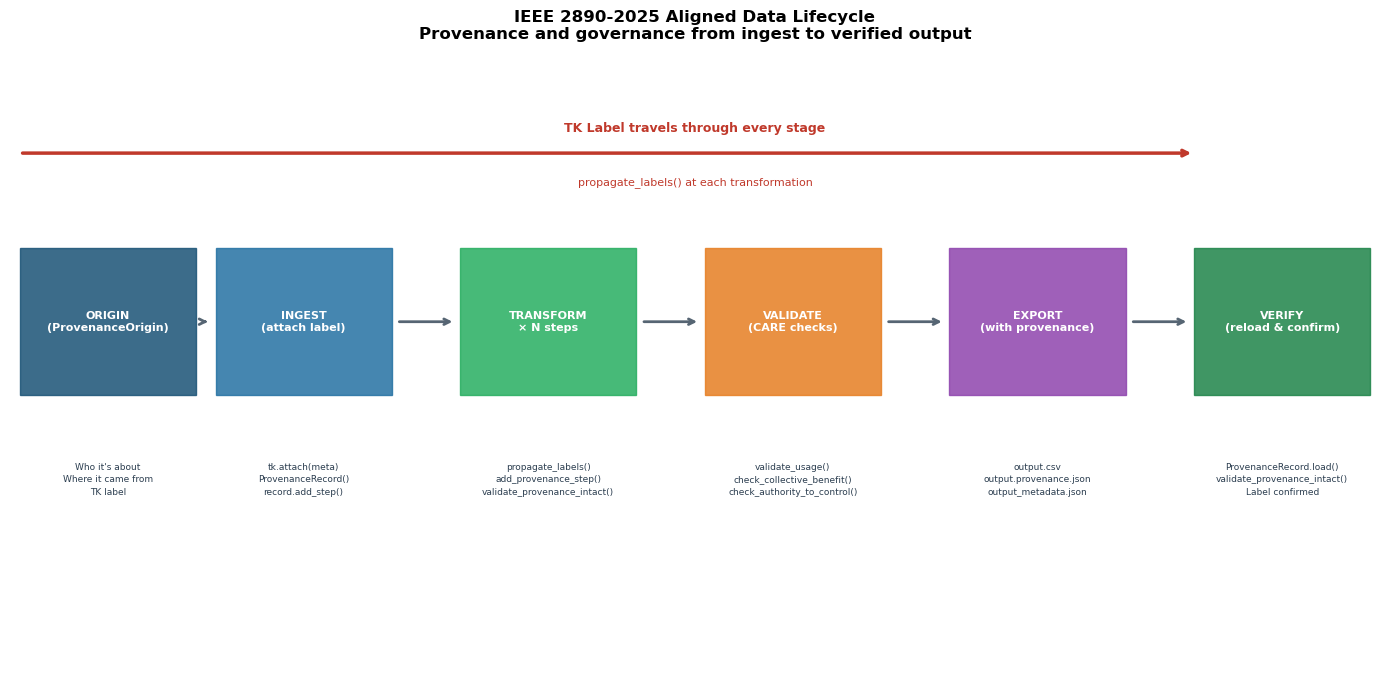

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(-0.5, 5.5)
ax.set_axis_off()

stages = [
    (1,   "ORIGIN\n(ProvenanceOrigin)",   "#1A5276",  "Who it's about\nWhere it came from\nTK label"),
    (3,   "INGEST\n(attach label)",        "#2471A3",  "tk.attach(meta)\nProvenanceRecord()\nrecord.add_step()"),
    (5.5, "TRANSFORM\n× N steps",          "#27AE60",  "propagate_labels()\nadd_provenance_step()\nvalidate_provenance_intact()"),
    (8,   "VALIDATE\n(CARE checks)",       "#E67E22",  "validate_usage()\ncheck_collective_benefit()\ncheck_authority_to_control()"),
    (10.5,"EXPORT\n(with provenance)",     "#8E44AD",  "output.csv\noutput.provenance.json\noutput_metadata.json"),
    (13,  "VERIFY\n(reload & confirm)",    "#1E8449",  "ProvenanceRecord.load()\nvalidate_provenance_intact()\nLabel confirmed"),
]

for x, label, color, detail in stages:
    ax.add_patch(plt.Rectangle((x - 0.9, 2.2), 1.8, 1.4,
                                color=color, alpha=0.85, zorder=2))
    ax.text(x, 2.9, label, ha="center", va="center",
            fontsize=8, fontweight="bold", color="white", zorder=3)
    ax.text(x, 1.4, detail, ha="center", va="center",
            fontsize=6.5, color="#2C3E50", zorder=3, linespacing=1.5)

# Arrows between stages
xs = [x for x, *_ in stages]
for i in range(len(xs) - 1):
    ax.annotate("",
                xy=(xs[i+1] - 0.95, 2.9),
                xytext=(xs[i] + 0.95, 2.9),
                arrowprops=dict(arrowstyle="->", color="#566573", lw=2))

# TK label travels through everything
ax.annotate("",
            xy=(12.1, 4.5), xytext=(0.1, 4.5),
            arrowprops=dict(arrowstyle="->", color="#C0392B", lw=2.5,
                            connectionstyle="arc3,rad=0"))
ax.text(7, 4.7, "TK Label travels through every stage",
        ha="center", fontsize=9, color="#C0392B", fontweight="bold")
ax.text(7, 4.2, "propagate_labels() at each transformation",
        ha="center", fontsize=8, color="#C0392B")

ax.set_title(
    "IEEE 2890-2025 Aligned Data Lifecycle\n"
    "Provenance and governance from ingest to verified output",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Summary: IEEE 2890-2025 Alignment
| IEEE 2890-2025 Parameter | localcontexts implementation |
|---|---|
| Subject (what data is about) | `ProvenanceOrigin.subject` |
| Community (who it is about) | `ProvenanceOrigin.community` and `tk:community` |
| Territory (geographic connection) | `ProvenanceOrigin.territory` |
| Source (where it came from) | `ProvenanceOrigin.source_name`, `source_url` |
| Cultural authority | `TKMetadata.label`, `TKMetadata.authority` |
| Transformation history | `ProvenanceRecord.chain` (list of `ProvenanceStep`) |
| Governance conditions | `TKMetadata.usage`, `validate_usage()` |
| Machine-readable lineage | `ProvenanceRecord.to_json()`/`.save()`/`.load()` |

## What This Enables
When every dataset in a geospatial workflow carries this provenance chain:
1. **Governance is automatic**: use restrictions are checked, not assumed
2. **Labels survive**: `propagate_labels()` at every step
3. **Accountability is documented**: CARE compliance recorded in metadata
4. **Lineage is machine-readable**: any downstream system can parse the chain
5. **Communities benefit**: data that describes Tribal lands carries the
   community's authority forward, not just the analyst's decisions

## Next Steps
- **Apply to your workflow:** Add `ProvenanceRecord` and `propagate_labels()`
  to your existing geospatial pipelines. The `localcontexts` package installs
  with `pip install -e ".[all]"` from this repository.

- **Obtain real labels:** Work with Local Contexts and the relevant Tribal
  Nations to obtain actual TK or BC labels for your datasets.
  https://localcontexts.org/

- **STAC integration:** The `prov:` and `tk:` namespace fields in this toolkit
  map directly to STAC item properties and can be added as a custom STAC
  extension for cloud-native geospatial workflows.

- **Cite the standard:** When publishing work that uses this framework,
  cite IEEE 2890-2025 and the Local Contexts initiative alongside your
  data sources.